In [1]:
import sys
print(sys.executable)


/Users/mohammedkhashif/Documents/BITS/sem-1/ML/Assignments/Assignment-2/venv/bin/python


In [2]:
from xgboost import XGBClassifier


In [4]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X = pd.get_dummies(X, drop_first=True)

feature_columns = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (734, 15)
Test shape: (184, 15)


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.885870,0.929699,0.871560,0.931373,0.900474,0.769383
1,Decision Tree,0.798913,0.792324,0.798165,0.852941,0.824645,0.591368
2,KNN,0.885870,0.935976,0.885714,0.911765,0.898551,0.768600
3,Naive Bayes,0.913043,0.945122,0.930000,0.911765,0.920792,0.824626
4,Random Forest,0.869565,0.930356,0.875000,0.892157,0.883495,0.735558
5,XGBoost,0.858696,0.921927,0.872549,0.872549,0.872549,0.714012


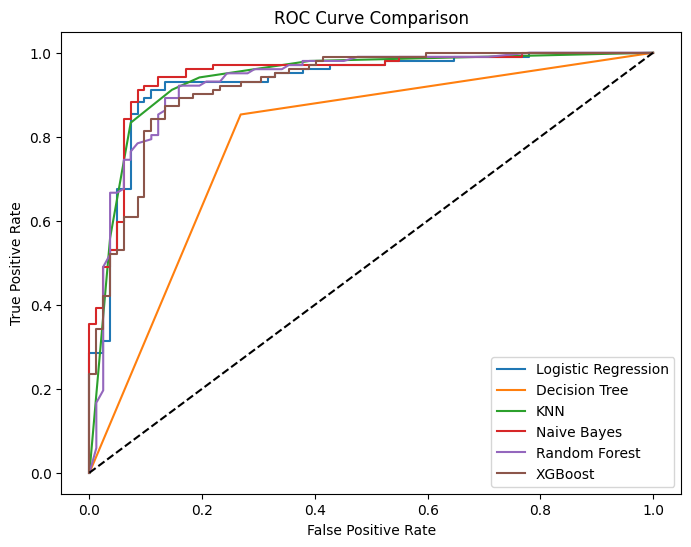

In [9]:
plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [10]:
import os
os.makedirs("model", exist_ok=True)

# Save models
for name, model in trained_models.items():
    filename = name.replace(" ", "_") + ".pkl"
    joblib.dump(model, f"model/{filename}")

# Save scaler
joblib.dump(scaler, "model/scaler.pkl")

# Save feature columns
joblib.dump(feature_columns, "model/feature_columns.pkl")

print("All models + scaler + feature columns saved successfully!")

All models + scaler + feature columns saved successfully!


In [14]:
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

st.set_page_config(page_title="Heart Disease Classification", layout="wide")

st.title("Heart Disease Prediction – ML Assignment 2")

st.markdown("Upload test dataset and select a model to evaluate.")

uploaded_file = st.file_uploader("Upload CSV File", type=["csv"])

model_name = st.selectbox(
    "Select Model",
    [
        "Logistic_Regression",
        "Decision_Tree",
        "KNN",
        "Naive_Bayes",
        "Random_Forest",
        "XGBoost"
    ]
)

if uploaded_file:

    data = pd.read_csv(uploaded_file)

    st.subheader("Uploaded Data Preview")
    st.dataframe(data.head())

    # Load saved objects
    model = joblib.load(f"model/{model_name}.pkl")
    scaler = joblib.load("model/scaler.pkl")
    feature_columns = joblib.load("model/feature_columns.pkl")

    # Preprocess uploaded data
    data = pd.get_dummies(data, drop_first=True)
    data = data.reindex(columns=feature_columns, fill_value=0)
    data_scaled = scaler.transform(data)

    predictions = model.predict(data_scaled)

    st.subheader("Predictions")
    st.write(predictions)

    # If target column exists
    if "HeartDisease" in data.columns:
        y_true = data["HeartDisease"]

        st.subheader("Classification Report")
        st.text(classification_report(y_true, predictions))

        st.subheader("Confusion Matrix")
        cm = confusion_matrix(y_true, predictions)

        fig, ax = plt.subplots()
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
        st.pyplot(fig)

2026-02-12 23:38:27.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.644 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.647 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 23:38:27.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar